In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hmean
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.dates as mdates
from scipy.interpolate import UnivariateSpline
import itertools
import gsw
from scipy.optimize import minimize
from scipy.interpolate import interp1d

In [27]:
def process_data(filepath):    
    # Load the CSV file into a DataFrame
    data_df = pd.read_csv(filepath)
    
    # Define constants for the number of header rows and the row indicating the start of data
    NUM_HEADER_ROWS = 14
    DATA_START_MARKER = "# Data"
    
    # Separate header rows and data rows
    header_rows = data_df.iloc[:NUM_HEADER_ROWS]
    data_rows = data_df[data_df["Code"] != DATA_START_MARKER]
    
    # Create a dictionary to store DataFrames for each code
    dataframes_dict = {}
    
    # Iterate through the header rows
    for _, row in header_rows.iterrows():
        # Extract the code and headers for this code
        code, *headers = row.dropna().values
        
        # Rename the columns in a temporary DataFrame based on the extracted headers
        rename_dict = {f"V{i+1}": header for i, header in enumerate(headers)}
        temp_df = data_rows.copy()
        temp_df.rename(columns=rename_dict, inplace=True)
        
        # Get the corresponding data rows based on the code
        corresponding_data_rows = temp_df[temp_df["Code"] == code]
        
        # If there are corresponding data rows:
        if not corresponding_data_rows.empty:
            # Set the first row as the header
            corresponding_data_rows.columns = corresponding_data_rows.iloc[0].values
            # Drop the first row (now header)
            corresponding_data_rows = corresponding_data_rows.drop(corresponding_data_rows.index[0])
            dataframes_dict[code] = corresponding_data_rows
            
    return dataframes_dict

def create_nested_dictionary(filepaths):
    """
    Process multiple files and return a dictionary containing dataframes for each file.
    The keys of the outer dictionary are the last 4 digits of the csv file name.
    """
    all_dfs = {}
    
    for filepath in filepaths:
        # Extracting the identifier from the filename (using the last 4 digits)
        identifier = filepath.split("_")[-2]
        
        all_dfs[identifier] = process_data(filepath)
        
    return all_dfs

# Check and convert to datetime if not already
def ensure_datetime(df, column_name):
    if not pd.api.types.is_datetime64_any_dtype(df[column_name]):
        df[column_name] = pd.to_datetime(df[column_name])
        
def remove_outliers(df, column_name):
    """
    Removes outliers from a dataframe based on the Interquartile Range (IQR) for a given column.
    """
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return only rows where the value is within the bounds
    return df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

def calculate_harmonic_mean(series1, series2):
    # Drop NaN values
    combined = pd.concat([series1, series2], axis=1).dropna()
    harmonic_values = hmean(combined, axis=1)
    return pd.Series(harmonic_values, index=combined.index)


# Function to iterate over timeseries or use a constant value
def iterate_or_constant(value):
    if isinstance(value, (list, np.ndarray)):
        return value
    else:
        return itertools.repeat(value)

# Function using GSW with TEOS-10 conversions
def velocity_timeseries_TEOS10(T_series, P_series_kPa, S_series):
    velocity_series = []
    for T, P_kPa, S in zip(iterate_or_constant(T_series), iterate_or_constant(P_series_kPa), iterate_or_constant(S_series)):
        P_dbar = P_kPa * 0.1  # Convert kPa to dbar
        SA = gsw.SA_from_SP(S, P_dbar, longitude, latitude)
        CT = gsw.CT_from_t(SA, T, P_dbar)
        velocity_series.append(gsw.sound_speed(SA, CT, P_dbar))
    return velocity_series

# Function using basic T, P, S with GSW
def velocity_timeseries_basic(T_series, P_series_kPa, S_series):
    velocity_series = []
    for T, P_kPa, S in zip(iterate_or_constant(T_series), iterate_or_constant(P_series_kPa), iterate_or_constant(S_series)):
        P_dbar = P_kPa * 0.1  # Convert kPa to dbar
        velocity_series.append(gsw.sound_speed(S, T, P_dbar))
    return velocity_series

# Function using Chen and Millero equation
def velocity_timeseries_chen_millero(T_series, P_series_kPa, S_series):
    velocity_series = []
    for T, P_kPa, S in zip(iterate_or_constant(T_series), iterate_or_constant(P_series_kPa), iterate_or_constant(S_series)):
        P_bar = P_kPa * 0.01  # Convert kPa to bar
        velocity_series.append(sound_speed_chen_millero(S, T, P_bar))
    return velocity_series

# Function to perform linear regression and extrapolation
def fit_and_extrapolate(df, start_time, end_time, target_time):
    subset = df[(df['time'] >= start_time) & (df['time'] <= end_time)]
    slope, intercept, _, _, _ = linregress(
        x=subset['time'].map(pd.Timestamp.timestamp),
        y=subset['sea_water_practical_salinity']
    )
    return slope * target_time.timestamp() + intercept

def apply_tilt_correction(df_range, baseline_tag, perturb_df,
                          dist_col="Calculated Distance (m)"):
    """
    Returns a copy of df_range with a new column 'Distance_tiltcorr(m)'.
    """
    col = f"{baseline_tag}_dL"
    merged = df_range.merge(perturb_df[[col]],
                            left_on="Record Time", right_index=True, how="left")
    merged["Distance_tiltcorr(m)"] = merged[dist_col] - merged[col]
    return merged

def apply_gap_mean_shift(sdf: pd.DataFrame,
                         gap_start: pd.Timestamp,
                         gap_end: pd.Timestamp,
                         pre_hours: int = 24,
                         post_hours: int = 24,
                         col: str = 'corrected_salinity',
                         overwrite: bool = True) -> pd.DataFrame:
    """
    Drops rows in [gap_start, gap_end) and shifts all rows with time >= gap_end
    by (mean_before - mean_after), where means are computed over
    [gap_start - pre_hours, gap_start) and [gap_end, gap_end + post_hours).
    """
    sdf = sdf.copy()
    # 1) drop gap rows
    in_gap = (sdf['time'] >= gap_start) & (sdf['time'] < gap_end)
    sdf = sdf[~in_gap].reset_index(drop=True)

    # 2) compute means
    pre_mask  = (sdf['time'] >= (gap_start - pd.Timedelta(hours=pre_hours))) & (sdf['time'] < gap_start)
    post_mask = (sdf['time'] >= gap_end) & (sdf['time'] < (gap_end + pd.Timedelta(hours=post_hours)))

    pre_vals  = sdf.loc[pre_mask, col].dropna()
    post_vals = sdf.loc[post_mask, col].dropna()

    if len(pre_vals) == 0 or len(post_vals) == 0:
        raise ValueError("Not enough data in pre/post windows to compute means. "
                         "Increase pre_hours/post_hours or adjust gap bounds.")

    pre_mean  = float(pre_vals.mean())
    post_mean = float(post_vals.mean())
    shift_amt = pre_mean - post_mean

    # 3) apply constant shift to all samples at/after gap_end
    after = sdf['time'] >= gap_end
    if overwrite:
        # keep a backup, then overwrite the main column
        sdf[col + '_before_gapfix'] = sdf[col].copy()
        sdf.loc[after, col] = sdf.loc[after, col] + shift_amt
    else:
        sdf[col + '_gapfix'] = sdf[col]
        sdf.loc[after, col + '_gapfix'] = sdf.loc[after, col + '_gapfix'] + shift_amt

    # print diagnostics
    print(f"[Gap fix] {gap_start} → {gap_end} | pre_mean={pre_mean:.5f} PSU, "
          f"post_mean={post_mean:.5f} PSU, applied shift={shift_amt:+.5f} PSU, "
          f"rows_dropped={int(in_gap.sum())}")

    return sdf

def parse_to_dataframe(data):
    lines = data.split('\n')
    parsed_data = [line.split() for line in lines if line]
    df = pd.DataFrame(parsed_data, columns=['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Value'])
    df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])
    df['Value'] = pd.to_numeric(df['Value'])
    df.drop(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'], axis=1, inplace=True)
    return df

# Function to find the closest time in the DataFrame to a given discrete point
def find_closest_time(df, target_time):
    absolute_difference = abs(df['time'] - target_time)
    closest_index = absolute_difference.idxmin()
    return df.loc[closest_index]

# Extrapolation function using linregress
def fit_and_extrapolate(df, start_time, end_time, target_time):
    subset = df[(df['time'] >= start_time) & (df['time'] <= end_time)]
    slope, intercept, _, _, _ = linregress(
        x=subset['time'].map(pd.Timestamp.timestamp),
        y=subset['adjusted_salinity']
    )
    return slope * target_time.timestamp() + intercept

def _interp_unique(df, t):
    """Interpolate Pitch/Roll onto timeline t, after dropping dup stamps."""
    tidy = (df.set_index("Record Time")
              .sort_index()
              .loc[lambda x: ~x.index.duplicated(keep="first")])
    return (tidy.reindex(t)
                .interpolate(limit_direction="both")
                .astype(float))

def _local_xy(df, h=H_TXR):
    pitch, roll = np.radians(df["Pitch"]), np.radians(df["Roll"])
    dx = h * np.sin(roll)       # starboard
    dy = h * np.sin(pitch)      # forward
    return dx.values, dy.values

def _to_enu(dx, dy, heading_deg):
    h = np.radians(heading_deg)
    east  = dx*np.sin(h) + dy*np.cos(h)
    north = dx*np.cos(h) - dy*np.sin(h)
    return east, north

def _unit(lat1, lon1, lat2, lon2):
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    mlat = np.radians((lat1 + lat2)/2)
    de, dn = dlon*np.cos(mlat)*R_EARTH, dlat*R_EARTH
    L = np.hypot(de, dn)
    return de/L, dn/L           # EN components of unit vector

# Optimization function
def optimize_tidal_influence(params, tidal_df, pressure_df):
    amplitude, rho = params
    adjusted_tidal = amplitude * tidal_df['Value']
    tidal_df['Adjusted Value'] = adjusted_tidal
    interpolated_tidal = tidal_df.reindex(pressure_df.index, method='nearest')['Adjusted Value']
    corrected_pressure = pressure_df['Pressure (kPa)'] - (rho * 9.81 * interpolated_tidal) * 0.001
    return np.var(corrected_pressure)


# Create a function to interpolate velocity
def interpolate_velocity(time_series, velocity_df):
    # Convert 'Record Time' to numeric for interpolation
    velocity_df['Record Time'] = pd.to_datetime(velocity_df['Record Time'])
    time_numeric = velocity_df['Record Time'].astype('int64')
    
    # Interpolator function
    interpolator = interp1d(time_numeric, velocity_df['SoundSpeed'], 
                            fill_value='extrapolate', bounds_error=False)
    
    # Apply interpolation
    return interpolator(pd.to_datetime(time_series).astype('int64'))


In [30]:
identifiers = ['2502', '2504']
titles = ["Filtered SSP for 2502", "Filtered SSP for 2504"]
colors = ['blue', 'orange']  # Adjusted color list to match the number of identifiers

# List of identifiers
identifiers = ["2504", "2503", "2502"]

# Extracting the data for each identifier
data_extracted = {}
for identifier in identifiers:
    data_extracted[identifier] = {
        "TMP": df_dict[identifier]["TMP"] if "TMP" in df_dict[identifier] else None,
        "DQZ": df_dict[identifier]["DQZ"] if "DQZ" in df_dict[identifier] else None,
        "INC": df_dict[identifier]["INC"] if "INC" in df_dict[identifier] else None
    }

# Converting columns to numeric type and removing NaN values
for identifier in identifiers:
    if data_extracted[identifier]["TMP"] is not None:
        data_extracted[identifier]["TMP"]["Temperature Deg C"] = pd.to_numeric(data_extracted[identifier]["TMP"]["Temperature Deg C"], errors='coerce')
        data_extracted[identifier]["TMP"].dropna(subset=["Temperature Deg C"], inplace=True)
    
    if data_extracted[identifier]["DQZ"] is not None:
        data_extracted[identifier]["DQZ"]["Pressure (kPa)"] = pd.to_numeric(data_extracted[identifier]["DQZ"]["Pressure (kPa)"], errors='coerce')
        data_extracted[identifier]["DQZ"].dropna(subset=["Pressure (kPa)"], inplace=True)
        
    if data_extracted[identifier]["DQZ"] is not None:
        data_extracted[identifier]["DQZ"]['Temperature (Deg C)'] = pd.to_numeric(data_extracted[identifier]["DQZ"]['Temperature (Deg C)'], errors='coerce')
        data_extracted[identifier]["DQZ"].dropna(subset=['Temperature (Deg C)'], inplace=True)
        
    if data_extracted[identifier]["INC"] is not None:
        data_extracted[identifier]["INC"]['Pitch (deg)'] = pd.to_numeric(data_extracted[identifier]["INC"]['Pitch (deg)'], errors='coerce')
        data_extracted[identifier]["INC"].dropna(subset=['Pitch (deg)'], inplace=True)  
        
    if data_extracted[identifier]["INC"] is not None:
        data_extracted[identifier]["INC"]['Roll (deg)'] = pd.to_numeric(data_extracted[identifier]["INC"]['Roll (deg)'], errors='coerce')
        data_extracted[identifier]["INC"].dropna(subset=['Roll (deg)'], inplace=True) 


for idx, identifier in enumerate(identifiers):
    # Removing outliers and plotting temperature
    if data_extracted[identifier]["TMP"] is not None:
        data_extracted[identifier]["TMP"] = remove_outliers(data_extracted[identifier]["TMP"], "Temperature Deg C")
    
    # Removing outliers and plotting pressure
    if data_extracted[identifier]["DQZ"] is not None:
        data_extracted[identifier]["DQZ"] = remove_outliers(data_extracted[identifier]["DQZ"], "Pressure (kPa)")
        data_extracted[identifier]["DQZ"] = remove_outliers(data_extracted[identifier]["DQZ"], 'Temperature (Deg C)')

    

In [31]:
# Initialize dictionaries to store the dataframes with harmonic means
harmonic_mean_dfs = {}

# Calculate harmonic means between the time series stored in 2502, 2503, and 2504
pairs = [('2502', '2503'), ('2502', '2504'), ('2503', '2504')]

# Calculate harmonic means between the time series stored in 2502, 2503, and 2504
for pair in pairs:
    df1 = result_dfs[pair[0]].set_index('Record Time')
    df2 = result_dfs[pair[1]].set_index('Record Time')
    df1 = df1[~df1.index.duplicated(keep='first')]
    df2 = df2[~df2.index.duplicated(keep='first')]
    
    # Calculate harmonic mean for each pair and create a new dataframe
    harmonic_mean = calculate_harmonic_mean(df1['SoundSpeed'], df2['SoundSpeed'])
    harmonic_mean_df = pd.DataFrame({
        'Record Time': harmonic_mean.index,
        'Harmonic Mean': harmonic_mean.values
    })
    
    harmonic_mean_dfs[f'{pair[0]}_{pair[1]}'] = harmonic_mean_df
    
# Updating the dataframes based on the instructions
harmonic_mean_dfs['2502_2503'] = harmonic_mean_dfs['2502_2504']
harmonic_mean_dfs['2503_2504'] = result_dfs['2504'][['Record Time', 'SoundSpeed']]

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.ndimage import uniform_filter1d


# Load the CSV into a DataFrame
file_path = '/data/wsd02/maleen_data/ooi-rs03ccal-mj03f-12-ctdpfb305_2f21_522e_6ceb.csv'
#ooi-rs03ccal-mj03f-12-ctdpfb305_fedb_e1a6_bd2b.csv'

df = pd.read_csv(file_path, usecols=[0, 1])

# Drop the first row (with units) and reset the index
df = df.drop(0).reset_index(drop=True)

# Convert the 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'])

# Filter out rows where 'sea_water_practical_salinity' is above 100 or below 34.48
df_filtered = df[(df['sea_water_practical_salinity'] <= 100) & (df['sea_water_practical_salinity'] >= 34.48)].copy()

# Remove timezone information from 'time'
df_filtered.loc[:, 'time'] = df_filtered['time'].dt.tz_localize(None)

smoothing_start_date = pd.to_datetime('2023-08-01')

# Find the index where smoothing should start
smoothing_start_index = df_filtered.index[df_filtered['time'] >= smoothing_start_date][0]

# Apply smoothing only to the portion after the start date
smoothed_salinity = uniform_filter1d(df_filtered['sea_water_practical_salinity'].iloc[smoothing_start_index:], size=250)

# Combine unchanged data with the smoothed portion
df_filtered['sea_water_practical_salinity'] = pd.concat([
    df_filtered['sea_water_practical_salinity'].iloc[:smoothing_start_index],
    pd.Series(smoothed_salinity, index=df_filtered.index[smoothing_start_index:])
])

# Define the range
start_time = pd.to_datetime('2022-08-14 05:49:53')
end_time = pd.to_datetime('2024-09-05 23:59:00')

# Filter the salinity data based on the defined range
mask = (df_filtered['time'] >= start_time) & (df_filtered['time'] <= end_time)
salinity_df = df_filtered.loc[mask].copy()


# Define the discrete points and their actual salinity values
discrete_points = pd.to_datetime(['2022-08-14 05:49:53', '2022-08-30 19:37:13', '2023-09-17 03:35:09'])
actual_salinity_values = [34.52543602, 34.5272034, 34.527000]



# First Correction: Adjust the entire series to align with the second discrete point
second_point_data = find_closest_time(salinity_df, discrete_points[1])
second_point_salinity = second_point_data['sea_water_practical_salinity']
salinity_adjustment = actual_salinity_values[1] - second_point_salinity
salinity_df.loc[:, 'adjusted_salinity'] = salinity_df['sea_water_practical_salinity'] + salinity_adjustment



# Third Correction: Drift correction for data between second and third discrete points
fit_start_2 = pd.to_datetime('2023-06-15 03:35:09')
fit_end_2 = pd.to_datetime('2024-09-07 23:59:00')
extrapolated_end_salinity = fit_and_extrapolate(salinity_df, fit_start_2, fit_end_2, discrete_points[2])
drift_correction_at_third_point = actual_salinity_values[2] - extrapolated_end_salinity

# Apply linear correction between the second and third discrete points
time_difference = discrete_points[2] - discrete_points[1]
salinity_df.loc[:, 'second_stage_corrected_salinity'] = salinity_df.apply(
    lambda row: row['adjusted_salinity'] + drift_correction_at_third_point * (1 - (discrete_points[2] - row['time']) / time_difference) if discrete_points[1] <= row['time'] <= discrete_points[2] else row['adjusted_salinity'], 
    axis=1
)

# New Correction: Adjust salinity values between first and second discrete points
fit_start_1 = pd.to_datetime('2022-08-14 15:54:00')
fit_end_1 = pd.to_datetime('2022-09-15 03:35:09')
extrapolated_first_point_salinity = fit_and_extrapolate(salinity_df, fit_start_1, fit_end_1, discrete_points[0])
drift_correction_at_first_point = actual_salinity_values[0] - extrapolated_first_point_salinity

# Apply linear correction between the first and second discrete points
time_difference = discrete_points[1] - discrete_points[0]
salinity_df.loc[:, 'corrected_salinity'] = salinity_df.apply(
    lambda row: row['second_stage_corrected_salinity'] + drift_correction_at_first_point * (1 - (row['time'] - discrete_points[0]) / time_difference) if discrete_points[0] <= row['time'] <= discrete_points[1] else row['second_stage_corrected_salinity'],
    axis=1
)


In [33]:
import pandas as pd
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.stats import linregress

# ─── USER INPUT ──────────────────────────────────────────────────────────
file_path = '/data/wsd02/maleen_data/ooi-rs03ccal-mj03f-12-ctdpfb305_2f21_522e_6ceb.csv'
#ooi-rs03ccal-mj03f-12-ctdpfb305_fedb_e1a6_bd2b.csv'

bottle_times = pd.to_datetime([
    '2022-08-14 05:49:53',      # t1
    '2022-08-30 19:37:13',      # t2
    '2023-09-17 03:35:09'       # t3
])
bottle_sal  = np.array([34.52543602, 34.52720340, 34.52700000])

# gap to delete
jump_start  = pd.to_datetime('2023-09-07 00:00:00')
jump_end    = pd.to_datetime('2023-09-14 00:00:00')      # first kept sample
smooth_after = jump_end                                  # smooth ≥ 14 Sep 2023
smooth_len   = 250                                       # samples

# analysis window (same as your original mask)
start_time = pd.to_datetime('2022-08-14 05:49:53')
end_time   = pd.to_datetime('2025-09-05 23:59:00')
# ─────────────────────────────────────────────────────────────────────────


# ─── 1. LOAD & BASIC FILTER  ────────────────────────────────────────────
df = pd.read_csv(file_path, usecols=[0, 1]).drop(0).reset_index(drop=True)
df.columns = ['time', 'sal_raw']
df['time']    = pd.to_datetime(df['time']).dt.tz_localize(None)
df['sal_raw'] = pd.to_numeric(df['sal_raw'], errors='coerce')
df = df[df['sal_raw'].between(34.48, 100)].copy()

# ─── 2. REMOVE GAP AND STITCH THE LEVELS  ───────────────────────────────
# a) delete rows in the gap
gap_mask = (df['time'] >= jump_start) & (df['time'] < jump_end)
df = df[~gap_mask].reset_index(drop=True)

#gap_mask = (df['time'] >= pd.to_datetime('2024-08-27 00:00:00')) & (df['time'] < pd.to_datetime('2024-11-07 00:00:00'))
#df = df[~gap_mask].reset_index(drop=True)

# b) compute level before & after the gap
pre_gap_val  = df.loc[df['time'] < jump_start, 'sal_raw'].iloc[-1]
post_gap_val = df.loc[df['time'] >= jump_end, 'sal_raw'].iloc[0]
gap_shift    = pre_gap_val - post_gap_val          # amount to add to post-gap

# c) apply the shift to the post-gap block
df.loc[df['time'] >= jump_end, 'sal_raw'] += gap_shift

# ─── 3. SMOOTH ONLY POST-GAP DATA  ──────────────────────────────────────
post_idx = df.index[df['time'] >= smooth_after]
if len(post_idx):
    df.loc[post_idx, 'sal_raw'] = uniform_filter1d(
        df.loc[post_idx, 'sal_raw'], size=smooth_len)

# ─── 4. BOTTLE-CALIBRATION LOGIC  (unchanged except for numeric cast) ──
def nearest_val(t):
    return df.iloc[(df['time'] - t).abs().argmin()]['sal_raw']

raw_b1, raw_b2 = map(nearest_val, bottle_times[:2])
Δ1 = bottle_sal[0] - raw_b1           # bias at t1
Δ2 = bottle_sal[1] - raw_b2           # bias at t2

t1, t2, t3 = bottle_times

# Offset from Bottle-1 → Bottle-2 (linear)
df['offset_A'] = 0.0
mask_A = (df['time'] >= t1) & (df['time'] <= t2)
w = (df.loc[mask_A, 'time'] - t1) / (t2 - t1)
df.loc[mask_A, 'offset_A'] = Δ1 + w * (Δ2 - Δ1)
df.loc[df['time'] > t2, 'offset_A'] = Δ2            # flat after t2

# Fit straight line through Segment-B (t2 → jump_start) after Δ2 shift
mask_B = (df['time'] > t2) & (df['time'] < jump_start)
if mask_B.any():
    slope, intercept, *_ = linregress(
        df.loc[mask_B, 'time'].astype('int64'),
        df.loc[mask_B, 'sal_raw'] + Δ2
    )
    S_pred_t3 = slope * int(t3.value) + intercept
else:
    S_pred_t3 = raw_b2 + Δ2

# Shift Segment-C (post-gap) so Bottle-3 is perfect
raw_b3 = nearest_val(t3)
shift_C = bottle_sal[2] - (raw_b3 + Δ2)

df['offset_C'] = 0.0
df.loc[df['time'] >= smooth_after, 'offset_C'] = shift_C

# Ramp that shift back into Segment-B to keep continuity
df['offset_P'] = 0.0
ramp_mask = (df['time'] > t2) & (df['time'] < jump_end)
if ramp_mask.any():
    rr = (df.loc[ramp_mask, 'time'] - t2) / (jump_end - t2)
    df.loc[ramp_mask, 'offset_P'] = rr * shift_C

# ─── 5. TOTAL CORRECTION & FINAL OUTPUT  ───────────────────────────────
df['total_offset'] = df['offset_A'] + df['offset_P'] + df['offset_C']
df['corrected_salinity'] = df['sal_raw'] + df['total_offset']

salinity_df = df[(df['time'] >= start_time) & (df['time'] <= end_time)].copy()

# OPTIONAL: print residuals at the three bottles
for bt, true_S in zip(bottle_times, bottle_sal):
    est = salinity_df.iloc[(salinity_df['time'] - bt).abs().argmin()]
    print(f"Residual @ {bt} : {(est['corrected_salinity']-true_S):+6.2e} PSU")

#  salinity_df now has your final calibrated series:
#     time, sal_raw, corrected_salinity, plus offset columns


Residual @ 2022-08-14 05:49:53 : +1.76e-02 PSU
Residual @ 2022-08-30 19:37:13 : +6.87e-05 PSU
Residual @ 2023-09-17 03:35:09 : +0.00e+00 PSU


In [34]:
import pandas as pd
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.stats import linregress

# ─── USER INPUT ──────────────────────────────────────────────────────────
file_path = '/data/wsd02/maleen_data/ooi-rs03ccal-mj03f-12-ctdpfb305_2f21_522e_6ceb.csv'

bottle_times = pd.to_datetime([
    '2022-08-14 05:49:53',      # t1
    '2022-08-30 19:37:13',      # t2
    '2023-09-17 03:35:09'       # t3
])
bottle_sal  = np.array([34.52543602, 34.52720340, 34.52700000])

# 2013 cal fix gap to delete (your original)
jump_start  = pd.to_datetime('2023-09-07 00:00:00')
jump_end    = pd.to_datetime('2023-09-14 00:00:00')      # first kept sample
smooth_after = jump_end                                  # smooth ≥ 14 Sep 2023
smooth_len   = 250                                       # samples

# analysis window
start_time = pd.to_datetime('2022-08-14 05:49:53')
end_time   = pd.to_datetime('2025-09-05 23:59:00')

# --- the August/September 2024 hard-gap step to correct ---
#   We will drop [gap_start_24, gap_end_24) and
#   shift every sample with time >= gap_end_24 by (pre_mean - post_mean).
gap_start_24 = pd.to_datetime('2024-08-31 21:43:00')
gap_end_24   = pd.to_datetime('2024-09-01 20:13:00')
pre_hours    = 24   # averaging window BEFORE gap_start_24
post_hours   = 24   # averaging window AFTER gap_end_24
# ─────────────────────────────────────────────────────────────────────────


# ─── 1) LOAD & BASIC FILTER ─────────────────────────────────────────────
df = pd.read_csv(file_path, usecols=[0, 1]).drop(0).reset_index(drop=True)
df.columns = ['time', 'sal_raw']
df['time']    = pd.to_datetime(df['time']).dt.tz_localize(None)
df['sal_raw'] = pd.to_numeric(df['sal_raw'], errors='coerce')
df = df[df['sal_raw'].between(34.48, 100)].copy()

# ─── 2) REMOVE THE 2023 GAP & STITCH LEVELS (your original logic) ──────
gap_mask = (df['time'] >= jump_start) & (df['time'] < jump_end)
df = df[~gap_mask].reset_index(drop=True)

pre_gap_val  = df.loc[df['time'] < jump_start, 'sal_raw'].iloc[-1]
post_gap_val = df.loc[df['time'] >= jump_end, 'sal_raw'].iloc[0]
gap_shift    = pre_gap_val - post_gap_val
df.loc[df['time'] >= jump_end, 'sal_raw'] += gap_shift

# smooth only post-2023-gap section
post_idx = df.index[df['time'] >= smooth_after]
if len(post_idx):
    df.loc[post_idx, 'sal_raw'] = uniform_filter1d(
        df.loc[post_idx, 'sal_raw'], size=smooth_len
    )

# ─── 3) BOTTLE CALIBRATION (unchanged) ─────────────────────────────────
def nearest_val(t):
    return df.iloc[(df['time'] - t).abs().argmin()]['sal_raw']

raw_b1, raw_b2 = map(nearest_val, bottle_times[:2])
d1 = bottle_sal[0] - raw_b1           # bias at t1
d2 = bottle_sal[1] - raw_b2           # bias at t2

t1, t2, t3 = bottle_times

# Offset from Bottle-1 → Bottle-2 (linear)
df['offset_A'] = 0.0
mask_A = (df['time'] >= t1) & (df['time'] <= t2)
w = (df.loc[mask_A, 'time'] - t1) / (t2 - t1)
df.loc[mask_A, 'offset_A'] = d1 + w * (d2 - d1)
df.loc[df['time'] > t2, 'offset_A'] = d2  # flat after t2

# Fit straight line through Segment-B (t2 → jump_start) after d2 shift
mask_B = (df['time'] > t2) & (df['time'] < jump_start)
if mask_B.any():
    slope, intercept, *_ = linregress(
        df.loc[mask_B, 'time'].astype('int64'),
        df.loc[mask_B, 'sal_raw'] + d2
    )

# Shift Segment-C (post-gap) so Bottle-3 is perfect
raw_b3 = nearest_val(t3)
shift_C = bottle_sal[2] - (raw_b3 + d2)
df['offset_C'] = 0.0
df.loc[df['time'] >= smooth_after, 'offset_C'] = shift_C

# Ramp that shift back into Segment-B to keep continuity across 2023 gap
df['offset_P'] = 0.0
ramp_mask = (df['time'] > t2) & (df['time'] < jump_end)
if ramp_mask.any():
    rr = (df.loc[ramp_mask, 'time'] - t2) / (jump_end - t2)
    df.loc[ramp_mask, 'offset_P'] = rr * shift_C

# total correction (pre-2024 step-fix)
df['total_offset'] = df['offset_A'] + df['offset_P'] + df['offset_C']
df['corrected_salinity'] = df['sal_raw'] + df['total_offset']

# apply analysis window
salinity_df = df[(df['time'] >= start_time) & (df['time'] <= end_time)].copy()

# OPTIONAL: report bottle residuals
for bt, true_S in zip(bottle_times, bottle_sal):
    est = salinity_df.iloc[(salinity_df['time'] - bt).abs().argmin()]
    print(f"Residual @ {bt} : {(est['corrected_salinity']-true_S):+6.2e} PSU")

# ─── 4) HARD-GAP + MEAN-SHIFT STEP CORRECTION (NO RAMPS) ───────────────


# Apply the requested 2024 gap+shift (no ramps)
salinity_df = apply_gap_mean_shift(
    salinity_df,
    gap_start=gap_start_24,
    gap_end=gap_end_24,
    pre_hours=pre_hours,
    post_hours=post_hours,
    col='corrected_salinity',
    overwrite=True   # overwrite corrected_salinity so your plotting code just works
)

# ─── 5) salinity_df is final ────────────────────────────────────────────
# Columns:
#   time, sal_raw, corrected_salinity (gap-fixed),
#   ... offset_A, offset_P, offset_C, total_offset, corrected_salinity_before_gapfix

# Example: quick plot (optional)
# import matplotlib.pyplot as plt
# plt.figure(figsize=(16,5))
# plt.plot(salinity_df['time'], salinity_df['corrected_salinity'])
# plt.xlabel('Time'); plt.ylabel('Salinity (PSU)'); plt.tight_layout(); plt.show()
# ─── 5) 2025 HARD GAPS + MEAN-SHIFTS (NO RAMPS) ─────────────────────────
# 1-hour gaps (±30 min) around each step, plus the wide July-7 gap you approved
gaps_2025 = [
    (pd.Timestamp('2025-06-27 02:21:00'), pd.Timestamp('2025-06-27 03:21:00')),
    (pd.Timestamp('2025-07-07 07:28:00'), pd.Timestamp('2025-07-07 16:17:00')),
    (pd.Timestamp('2025-07-15 07:34:00'), pd.Timestamp('2025-07-15 08:34:00')),
    (pd.Timestamp('2025-08-16 22:36:00'), pd.Timestamp('2025-08-16 23:36:00')),
    (pd.Timestamp('2025-08-25 11:19:00'), pd.Timestamp('2025-08-25 12:19:00')),
]

for s, e in gaps_2025:
    salinity_df = apply_gap_mean_shift(
        salinity_df,
        gap_start=s,
        gap_end=e,
        pre_hours=24,
        post_hours=24,
        col='corrected_salinity',
        overwrite=True  # in-place level alignment of post-gap block
    )

# salinity_df now contains the final corrected series (2024 + all 2025 fixes)


Residual @ 2022-08-14 05:49:53 : +1.76e-02 PSU
Residual @ 2022-08-30 19:37:13 : +6.87e-05 PSU
Residual @ 2023-09-17 03:35:09 : +0.00e+00 PSU
[Gap fix] 2024-08-31 21:43:00 → 2024-09-01 20:13:00 | pre_mean=34.51568 PSU, post_mean=34.53672 PSU, applied shift=-0.02105 PSU, rows_dropped=147
[Gap fix] 2025-06-27 02:21:00 → 2025-06-27 03:21:00 | pre_mean=34.49028 PSU, post_mean=34.48072 PSU, applied shift=+0.00956 PSU, rows_dropped=60
[Gap fix] 2025-07-07 07:28:00 → 2025-07-07 16:17:00 | pre_mean=34.48842 PSU, post_mean=34.47704 PSU, applied shift=+0.01139 PSU, rows_dropped=58
[Gap fix] 2025-07-15 07:34:00 → 2025-07-15 08:34:00 | pre_mean=34.49418 PSU, post_mean=34.49430 PSU, applied shift=-0.00012 PSU, rows_dropped=60
[Gap fix] 2025-08-16 22:36:00 → 2025-08-16 23:36:00 | pre_mean=34.49927 PSU, post_mean=34.51071 PSU, applied shift=-0.01145 PSU, rows_dropped=60
[Gap fix] 2025-08-25 11:19:00 → 2025-08-25 12:19:00 | pre_mean=34.50309 PSU, post_mean=34.51651 PSU, applied shift=-0.01342 PSU, rows

In [39]:
import pandas as pd

# Convert the 'Record Time' to datetime and set as index for pressure DataFrame
pressure_df4 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2504']['DQZ']['Record Time']),
    'Pressure (kPa)': data_extracted['2504']['DQZ']['Pressure (kPa)']
}).set_index('Record Time')

DQZtemp_df4 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2504']['DQZ']['Record Time']),
    'Temperature Deg C': data_extracted['2504']['DQZ']['Temperature (Deg C)']
}).set_index('Record Time')

# Convert the 'Record Time' to datetime and set as index for temperature DataFrame
temperature_df4 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2504']['TMP']['Record Time']),
    'Temperature Deg C': data_extracted['2504']['TMP']['Temperature Deg C']+0.351
}).set_index('Record Time')

INC_df4 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2504']['INC']['Record Time']),
    'Pitch': data_extracted['2504']['INC']['Pitch (deg)'],
    'Roll': data_extracted['2504']['INC']['Roll (deg)']
})

# Merge pressure and temperature data on their indexes (Record Time)
combined_df4 = pressure_df4.join(temperature_df4, how='left')
DQZtemp_df4 = DQZtemp_df4[~DQZtemp_df4.index.duplicated(keep='first')]
combined_df4['TempDQZ']=DQZtemp_df4['Temperature Deg C']

# Now, for salinity, which has different times, let's create a DataFrame and reindex it to the pressure times,
# filling missing values by interpolating or forward-filling (depending on your needs)
salinity_dfs4 = pd.DataFrame({
    'time': pd.to_datetime(salinity_df['time']),
    'adjusted_salinity': salinity_df['corrected_salinity']
}).set_index('time')

# Reindex the salinity data to match the pressure record times, forward-filling values
aligned_salinity_df4 = salinity_dfs4.reindex(combined_df4.index, method='nearest')

# Add the aligned salinity data to the combined dataframe
combined_df4['Salinity'] = aligned_salinity_df4['adjusted_salinity']

# Reset index to make 'Record Time' a column again, if needed
combined_df4.reset_index(inplace=True)

# Rename the index to 'Record Time'
combined_df4.rename(columns={'index': 'Record Time'}, inplace=True)

combined_df4

/tmp/ipykernel_1763391/1096220134.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2504']['DQZ']['Record Time']),
/tmp/ipykernel_1763391/1096220134.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2504']['DQZ']['Record Time']),
/tmp/ipykernel_1763391/1096220134.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2504']['TMP']['Record Time']),
/tmp/ipykernel_1763391/1096220134.py:21: UserWarning: Could not infer format, so each ele

,Record Time,Pressure (kPa),Temperature Deg C,TempDQZ,Salinity
0,2022-09-02 11:45:00,15566.25195,2.3874,2.46,34.529143
1,2022-09-02 15:45:00,15559.93652,2.3825,2.42,34.528767
2,2022-09-02 19:45:00,15560.09082,2.3819,2.41,34.528866
3,2022-09-02 23:45:00,15572.06641,2.3801,2.41,34.530268
4,2022-09-03 03:45:00,15561.18164,2.3734,2.40,34.530916
...,...,...,...,...,...
6367,2025-08-08 11:45:00,15550.15527,2.4266,2.46,34.500968
6368,2025-08-08 15:45:00,15547.49219,2.4212,2.45,34.501619
6369,2025-08-08 19:45:00,15564.73438,2.3961,2.43,34.503449
6370,2025-08-08 23:45:00,15559.08008,2.4008,2.43,34.502892


In [40]:
# Convert the 'Record Time' to datetime and set as index for pressure DataFrame
pressure_df3 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2503']['DQZ']['Record Time']),
    'Pressure (kPa)': data_extracted['2503']['DQZ']['Pressure (kPa)']
}).set_index('Record Time')

# Convert the 'Record Time' to datetime and set as index for temperature DataFrame
temperature_df3 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2503']['TMP']['Record Time']),
    'Temperature Deg C': data_extracted['2503']['TMP']['Temperature Deg C']
}).set_index('Record Time')

INC_df3 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2503']['INC']['Record Time']),
    'Pitch': data_extracted['2503']['INC']['Pitch (deg)'],
    'Roll': data_extracted['2503']['INC']['Roll (deg)']
})

# Merge pressure and temperature data on their indexes (Record Time)
combined_df3 = pressure_df3.join(temperature_df3, how='left')

# Now, for salinity, which has different times, let's create a DataFrame and reindex it to the pressure times,
# filling missing values by interpolating or forward-filling (depending on your needs)
salinity_dfs3 = pd.DataFrame({
    'time': pd.to_datetime(salinity_df['time']),
    'adjusted_salinity': salinity_df['corrected_salinity']
}).set_index('time')

# Reindex the salinity data to match the pressure record times, forward-filling values
aligned_salinity_df3 = salinity_dfs3.reindex(combined_df3.index, method='nearest')

# Add the aligned salinity data to the combined dataframe
combined_df3['Salinity'] = aligned_salinity_df3['adjusted_salinity']

# Reset index to make 'Record Time' a column again, if needed
combined_df3.reset_index(inplace=True)

# Rename the index to 'Record Time'
combined_df3.rename(columns={'index': 'Record Time'}, inplace=True)

combined_df3

/tmp/ipykernel_1763391/157872060.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2503']['DQZ']['Record Time']),
/tmp/ipykernel_1763391/157872060.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2503']['TMP']['Record Time']),
/tmp/ipykernel_1763391/157872060.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2503']['INC']['Record Time']),


,Record Time,Pressure (kPa),Temperature Deg C,Salinity
0,2022-09-01 11:45:00,14238.10840,2.4701,34.529692
1,2022-09-01 15:45:00,14226.72168,2.4791,34.529872
2,2022-09-01 19:45:00,14230.87500,2.4605,34.529953
3,2022-09-01 23:45:00,14242.19531,2.4770,34.529017
4,2022-09-02 03:45:00,14227.35742,2.4654,34.529698
...,...,...,...,...
6511,2025-08-23 11:45:00,14226.47852,2.5052,34.500820
6512,2025-08-23 15:45:00,14218.37305,2.5057,34.500820
6513,2025-08-23 19:45:00,14238.30273,2.5083,34.500820
6514,2025-08-23 23:45:00,14232.34570,2.4580,34.500820


In [37]:
# Convert the 'Record Time' to datetime and set as index for pressure DataFrame
pressure_df = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2502']['DQZ']['Record Time']),
    'Pressure (kPa)': data_extracted['2502']['DQZ']['Pressure (kPa)']
}).set_index('Record Time')

# Convert the 'Record Time' to datetime and set as index for temperature DataFrame
temperature_df1 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2502']['TMP']['Record Time']),
    'Temperature Deg C': data_extracted['2502']['TMP']['Temperature Deg C']
}).set_index('Record Time')

INC_df2 = pd.DataFrame({
    'Record Time': pd.to_datetime(data_extracted['2502']['INC']['Record Time']),
    'Pitch': data_extracted['2502']['INC']['Pitch (deg)'],
    'Roll': data_extracted['2502']['INC']['Roll (deg)']
})

# Merge pressure and temperature data on their indexes (Record Time)
combined_df2 = pressure_df.join(temperature_df1, how='left')

# Now, for salinity, which has different times, let's create a DataFrame and reindex it to the pressure times,
# filling missing values by interpolating or forward-filling (depending on your needs)
salinity_dfs2 = pd.DataFrame({
    'time': pd.to_datetime(salinity_df['time']),
    'adjusted_salinity': salinity_df['corrected_salinity']
}).set_index('time')

# Reindex the salinity data to match the pressure record times, forward-filling values
aligned_salinity_df2 = salinity_dfs2.reindex(combined_df2.index, method='nearest')

# Add the aligned salinity data to the combined dataframe
combined_df2['Salinity'] = aligned_salinity_df2['adjusted_salinity']

# Reset index to make 'Record Time' a column again, if needed
combined_df2.reset_index(inplace=True)

# Rename the index to 'Record Time'
combined_df2.rename(columns={'index': 'Record Time'}, inplace=True)

combined_df2

/tmp/ipykernel_1763391/3450790460.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2502']['DQZ']['Record Time']),
/tmp/ipykernel_1763391/3450790460.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2502']['TMP']['Record Time']),
/tmp/ipykernel_1763391/3450790460.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  'Record Time': pd.to_datetime(data_extracted['2502']['INC']['Record Time']),


,Record Time,Pressure (kPa),Temperature Deg C,Salinity
0,2022-09-01 03:45:00,14944.34961,2.4105,34.528726
1,2022-09-01 07:45:00,14947.29102,2.4100,34.529853
2,2022-09-01 11:45:00,14957.96484,2.4219,34.529692
3,2022-09-01 15:45:00,14946.54980,2.3971,34.529872
4,2022-09-01 19:45:00,14950.74512,2.4007,34.529953
...,...,...,...,...
6397,2025-08-08 15:45:00,14939.21094,2.4784,34.501619
6398,2025-08-08 19:45:00,14956.49023,2.4668,34.503449
6399,2025-08-08 23:45:00,14950.88379,2.4278,34.502892
6400,2025-08-09 03:45:00,14951.08008,2.3937,34.501385


In [41]:
INC_df3 = INC_df3[(INC_df3['Pitch'] < -3) & (INC_df3['Pitch'] > -3.5)]
INC_dfs3 = INC_df3[(INC_df3['Roll'] < 0)]
INC_df2 = INC_df2[(INC_df2['Roll'] < 0) & (INC_df2['Roll']> -0.35)]


In [42]:
import numpy as np
import pandas as pd

# ──────────────────────────────────────────────────────────────────────────────
# 0)  INC tables + metadata
# ──────────────────────────────────────────────────────────────────────────────
stations = {
    "2502": dict(inc=INC_df2, lat=45.96257971, lon=-129.9910622, heading=120),
    "2503": dict(inc=INC_df3, lat=45.94700845, lon=-130.0265777, heading=195),
    "2504": dict(inc=INC_df4, lat=45.95882833, lon=-130.0114997, heading=127),
}

# Baselines you want to correct (tx → rx)
pairs = [("2504", "2502"),   # baseline in filtered_bsl_2502_copy
         ("2504", "2503"),   #   »      in filtered_bsl_2503_copy   (example)
         ("2502", "2503")]   #   »      in filtered_bsl_2503_2502_copy

# ──────────────────────────────────────────────────────────────────────────────
# 1) helper functions
# ──────────────────────────────────────────────────────────────────────────────
R_EARTH = 6_371_000.0           # m
H_TXR   = 0.30                  # transducer ↔ tilt-sensor lever arm [m]

def _interp_unique(df, t):
    """Interpolate Pitch/Roll onto timeline t, after dropping dup stamps."""
    tidy = (df.set_index("Record Time")
              .sort_index()
              .loc[lambda x: ~x.index.duplicated(keep="first")])
    return (tidy.reindex(t)
                .interpolate(limit_direction="both")
                .astype(float))

def _local_xy(df, h=H_TXR):
    pitch, roll = np.radians(df["Pitch"]), np.radians(df["Roll"])
    dx = h * np.sin(roll)       # starboard
    dy = h * np.sin(pitch)      # forward
    return dx.values, dy.values

def _to_enu(dx, dy, heading_deg):
    h = np.radians(heading_deg)
    east  = dx*np.sin(h) + dy*np.cos(h)
    north = dx*np.cos(h) - dy*np.sin(h)
    return east, north

def _unit(lat1, lon1, lat2, lon2):
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    mlat = np.radians((lat1 + lat2)/2)
    de, dn = dlon*np.cos(mlat)*R_EARTH, dlat*R_EARTH
    L = np.hypot(de, dn)
    return de/L, dn/L           # EN components of unit vector

# ──────────────────────────────────────────────────────────────────────────────
# 2) build one-way baseline-change table
# ──────────────────────────────────────────────────────────────────────────────
series_list = []

for tx, rx in pairs:
    S_tx, S_rx = stations[tx], stations[rx]

    # common timeline (union of both inclinometer traces)
    timeline = pd.Index(sorted(set(S_tx["inc"]["Record Time"])
                               | set(S_rx["inc"]["Record Time"])))

    # interpolate, convert to ENU
    inc_tx = _interp_unique(S_tx["inc"], timeline)
    inc_rx = _interp_unique(S_rx["inc"], timeline)
    e_tx, n_tx = _to_enu(*_local_xy(inc_tx), S_tx["heading"])
    e_rx, n_rx = _to_enu(*_local_xy(inc_rx), S_rx["heading"])

    # project offsets onto baseline
    ue, un = _unit(S_tx["lat"], S_tx["lon"], S_rx["lat"], S_rx["lon"])
    dL_oneway = (e_tx - e_rx)*ue + (n_tx - n_rx)*un   # metres

    series_list.append(
        pd.DataFrame({f"{tx}-{rx}_dL": dL_oneway}, index=timeline)
    )

baseline_perturb = pd.concat(series_list, axis=1).sort_index()
cols = [c for c in baseline_perturb.columns if c.endswith('_dL')]

In [45]:
#new correction model
import pandas as pd
import numpy as np
from scipy.optimize import least_squares

def parse_to_dataframe(data):
    lines = data.split('\n')
    parsed_data = [line.split() for line in lines if line]
    df = pd.DataFrame(parsed_data, columns=['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Value'])
    df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])
    df['Value'] = pd.to_numeric(df['Value'])
    df.drop(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'], axis=1, inplace=True)
    return df

# Reading the contents of the files
with open('/data/wsd02/maleen_data/pred_F_2022.txt', 'r') as file_2022, open('/data/wsd02/maleen_data/pred_F_2023.txt', 'r') as file_2023, open('/data/wsd02/maleen_data/pred_F_2024.txt', 'r') as file_2024, open('/data/wsd02/maleen_data/pred_F_2025.txt', 'r') as file_2025:
    data_2022 = file_2022.read()
    data_2023 = file_2023.read()
    data_2024 = file_2024.read()
    data_2025 = file_2025.read()

df_2022 = parse_to_dataframe(data_2022)
df_2023 = parse_to_dataframe(data_2023)
df_2024 = parse_to_dataframe(data_2024)
df_2025 = parse_to_dataframe(data_2025)

tidal_df = pd.concat([df_2022, df_2023, df_2024, df_2025], ignore_index=True)
tidal_df.set_index('DateTime', inplace=True)

# Assuming combined_df4 is already defined and contains pressure data
#combined_df4['Pressure (kPa)'] and combined_df4['Record Time']

# Convert 'Record Time' to DateTime and set as index
combined_df4['DateTime'] = pd.to_datetime(combined_df4['Record Time'])
combined_df4.set_index('DateTime', inplace=True)

# Optimization function
def optimize_tidal_influence(params, tidal_df, pressure_df):
    amplitude, rho = params
    adjusted_tidal = amplitude * tidal_df['Value']
    tidal_df['Adjusted Value'] = adjusted_tidal
    interpolated_tidal = tidal_df.reindex(pressure_df.index, method='nearest')['Adjusted Value']
    corrected_pressure = pressure_df['Pressure (kPa)'] - (rho * 9.81 * interpolated_tidal) * 0.001
    return np.var(corrected_pressure)

# Initial guesses for amplitude, phase, and rho
initial_amplitude = 1  # Adjust based on your data
initial_phase = 0      # Adjust based on your data
initial_rho = 1025     # Initial guess for the density of seawater (kg/m^3)

# Perform optimization
result = least_squares(optimize_tidal_influence, x0=[initial_amplitude, initial_rho],
                       args=(tidal_df, combined_df4))

optimized_amplitude, optimized_rho = result.x

# Apply optimized parameters
tidal_df['Adjusted Value'] = optimized_amplitude * tidal_df['Value']
combined_df4['Tidal Influence (kPa)'] = (optimized_rho * 9.81 * tidal_df.reindex(combined_df4.index, method='nearest')['Adjusted Value']) * 0.001
combined_df4['Corrected Pressure (kPa)'] = combined_df4['Pressure (kPa)'] - combined_df4['Tidal Influence (kPa)']

# Proceed with any further analysis or steps as needed
# Reset the index to make 'Record Time' a column again
combined_df4.reset_index(inplace=True)

#del tidal_df
combined_df4

,DateTime,Record Time,Pressure (kPa),Temperature Deg C,TempDQZ,Salinity,Tidal Influence (kPa),Corrected Pressure (kPa)
0,2022-09-02 11:45:00,2022-09-02 11:45:00,15566.25195,2.3874,2.46,34.529143,4.636437,15561.615513
1,2022-09-02 15:45:00,2022-09-02 15:45:00,15559.93652,2.3825,2.42,34.528767,-1.729645,15561.666165
2,2022-09-02 19:45:00,2022-09-02 19:45:00,15560.09082,2.3819,2.41,34.528866,-1.617290,15561.708110
3,2022-09-02 23:45:00,2022-09-02 23:45:00,15572.06641,2.3801,2.41,34.530268,10.595362,15561.471048
4,2022-09-03 03:45:00,2022-09-03 03:45:00,15561.18164,2.3734,2.40,34.530916,-0.327787,15561.509427
...,...,...,...,...,...,...,...,...
6367,2025-08-08 11:45:00,2025-08-08 11:45:00,15550.15527,2.4266,2.46,34.500968,-8.625546,15558.780816
6368,2025-08-08 15:45:00,2025-08-08 15:45:00,15547.49219,2.4212,2.45,34.501619,-11.473585,15558.965775
6369,2025-08-08 19:45:00,2025-08-08 19:45:00,15564.73438,2.3961,2.43,34.503449,5.840386,15558.893994
6370,2025-08-08 23:45:00,2025-08-08 23:45:00,15559.08008,2.4008,2.43,34.502892,0.369018,15558.711062


In [46]:
#new correction model
import pandas as pd
import numpy as np
from scipy.optimize import least_squares

# Convert 'Record Time' to DateTime and set as index
combined_df3['DateTime'] = pd.to_datetime(combined_df3['Record Time'])
combined_df3.set_index('DateTime', inplace=True)

# Optimization function
def optimize_tidal_influence(params, tidal_df, pressure_df):
    amplitude, rho = params
    adjusted_tidal = amplitude * tidal_df['Value']
    tidal_df['Adjusted Value3'] = adjusted_tidal
    interpolated_tidal = tidal_df.reindex(pressure_df.index, method='nearest')['Adjusted Value3']
    corrected_pressure = pressure_df['Pressure (kPa)'] - (rho * 9.81 * interpolated_tidal) * 0.001
    return np.var(corrected_pressure)

# Initial guesses for amplitude, phase, and rho
initial_amplitude = 1  # Adjust based on your data
initial_phase = 0      # Adjust based on your data
initial_rho = 1025     # Initial guess for the density of seawater (kg/m^3)

# Perform optimization
result = least_squares(optimize_tidal_influence, x0=[initial_amplitude, initial_rho],
                       args=(tidal_df, combined_df3))

optimized_amplitude, optimized_rho = result.x

# Apply optimized parameters
tidal_df['Adjusted Value3'] = optimized_amplitude * tidal_df['Value']
combined_df3['Tidal Influence (kPa)'] = (optimized_rho * 9.81 * tidal_df.reindex(combined_df3.index, method='nearest')['Adjusted Value3']) * 0.001
combined_df3['Corrected Pressure (kPa)'] = combined_df3['Pressure (kPa)'] - combined_df3['Tidal Influence (kPa)']

# Proceed with any further analysis or steps as needed
# Reset the index to make 'Record Time' a column again
combined_df3.reset_index(inplace=True)
combined_df3

,DateTime,Record Time,Pressure (kPa),Temperature Deg C,Salinity,Tidal Influence (kPa),Corrected Pressure (kPa)
0,2022-09-01 11:45:00,2022-09-01 11:45:00,14238.10840,2.4701,34.529692,6.558576,14231.549824
1,2022-09-01 15:45:00,2022-09-01 15:45:00,14226.72168,2.4791,34.529872,-4.997647,14231.719327
2,2022-09-01 19:45:00,2022-09-01 19:45:00,14230.87500,2.4605,34.529953,-0.644127,14231.519127
3,2022-09-01 23:45:00,2022-09-01 23:45:00,14242.19531,2.4770,34.529017,10.774215,14231.421095
4,2022-09-02 03:45:00,2022-09-02 03:45:00,14227.35742,2.4654,34.529698,-4.168307,14231.525727
...,...,...,...,...,...,...,...
6511,2025-08-23 11:45:00,2025-08-23 11:45:00,14226.47852,2.5052,34.500820,-4.744524,14231.223044
6512,2025-08-23 15:45:00,2025-08-23 15:45:00,14218.37305,2.5057,34.500820,-12.672642,14231.045692
6513,2025-08-23 19:45:00,2025-08-23 19:45:00,14238.30273,2.5083,34.500820,7.237688,14231.065042
6514,2025-08-23 23:45:00,2025-08-23 23:45:00,14232.34570,2.4580,34.500820,1.349992,14230.995708


In [47]:
#new correction model
import pandas as pd
import numpy as np
from scipy.optimize import least_squares

# Convert 'Record Time' to DateTime and set as index
combined_df2['DateTime'] = pd.to_datetime(combined_df2['Record Time'])
combined_df2.set_index('DateTime', inplace=True)

# Optimization function
def optimize_tidal_influence(params, tidal_df, pressure_df):
    amplitude, rho = params
    adjusted_tidal = amplitude * tidal_df['Value']
    tidal_df['Adjusted Value2'] = adjusted_tidal
    interpolated_tidal = tidal_df.reindex(pressure_df.index, method='nearest')['Adjusted Value2']
    corrected_pressure = pressure_df['Pressure (kPa)'] - (rho * 9.81 * interpolated_tidal) * 0.001
    return np.var(corrected_pressure)

# Initial guesses for amplitude, phase, and rho
initial_amplitude = 1  # Adjust based on your data
initial_phase = 0      # Adjust based on your data
initial_rho = 1025     # Initial guess for the density of seawater (kg/m^3)

# Perform optimization
result = least_squares(optimize_tidal_influence, x0=[initial_amplitude, initial_rho],
                       args=(tidal_df, combined_df2))

optimized_amplitude, optimized_rho = result.x

# Apply optimized parameters
tidal_df['Adjusted Value2'] = optimized_amplitude * tidal_df['Value']
combined_df2['Tidal Influence (kPa)'] = (optimized_rho * 9.81 * tidal_df.reindex(combined_df2.index, method='nearest')['Adjusted Value2']) * 0.001
combined_df2['Corrected Pressure (kPa)'] = combined_df2['Pressure (kPa)'] - combined_df2['Tidal Influence (kPa)']

# Proceed with any further analysis or steps as needed
# Reset the index to make 'Record Time' a column again
combined_df2.reset_index(inplace=True)
combined_df2

,DateTime,Record Time,Pressure (kPa),Temperature Deg C,Salinity,Tidal Influence (kPa),Corrected Pressure (kPa)
0,2022-09-01 03:45:00,2022-09-01 03:45:00,14944.34961,2.4105,34.528726,-6.909273,14951.258883
1,2022-09-01 07:45:00,2022-09-01 07:45:00,14947.29102,2.4100,34.529853,-4.054210,14951.345230
2,2022-09-01 11:45:00,2022-09-01 11:45:00,14957.96484,2.4219,34.529692,6.572109,14951.392731
3,2022-09-01 15:45:00,2022-09-01 15:45:00,14946.54980,2.3971,34.529872,-5.007960,14951.557760
4,2022-09-01 19:45:00,2022-09-01 19:45:00,14950.74512,2.4007,34.529953,-0.645457,14951.390577
...,...,...,...,...,...,...,...
6397,2025-08-08 15:45:00,2025-08-08 15:45:00,14939.21094,2.4784,34.501619,-11.476961,14950.687901
6398,2025-08-08 19:45:00,2025-08-08 19:45:00,14956.49023,2.4668,34.503449,5.842104,14950.648126
6399,2025-08-08 23:45:00,2025-08-08 23:45:00,14950.88379,2.4278,34.502892,0.369127,14950.514663
6400,2025-08-09 03:45:00,2025-08-09 03:45:00,14951.08008,2.3937,34.501385,0.542349,14950.537731


In [48]:
from scipy.interpolate import interp1d
# Create a function to interpolate velocity
def interpolate_velocity(time_series, velocity_df):
    # Convert 'Record Time' to numeric for interpolation
    velocity_df['Record Time'] = pd.to_datetime(velocity_df['Record Time'])
    time_numeric = velocity_df['Record Time'].astype('int64')
    
    # Interpolator function
    interpolator = interp1d(time_numeric, velocity_df['SoundSpeed'], 
                            fill_value='extrapolate', bounds_error=False)
    
    # Apply interpolation
    return interpolator(pd.to_datetime(time_series).astype('int64'))

# Apply interpolation to get velocity values for combined_df4 datetimes
combined_df4['Record Time'] = pd.to_datetime(combined_df4['Record Time'])
combined_df4['interp_v'] = interpolate_velocity(combined_df4['Record Time'], result_dfs['2504'])

combined_df3['Record Time'] = pd.to_datetime(combined_df3['Record Time'])
combined_df3['interp_v'] = interpolate_velocity(combined_df3['Record Time'], result_dfs['2503'])

combined_df2['Record Time'] = pd.to_datetime(combined_df2['Record Time'])
combined_df2['interp_v'] = interpolate_velocity(combined_df2['Record Time'], result_dfs['2502'])

In [49]:
# Define constants
longitude = -130.01149966
latitude = 45.95882833

# Example DataFrame columns
T_series = np.array(combined_df4['Temperature Deg C'])
P_series_kPa = np.array(combined_df4['Pressure (kPa)'])

# If salinity is a constant
S_constant =  np.array(combined_df4['Salinity'])  # Assuming salinity is a constant value

# Call the functions with timeseries data or constants
TEOS10_4 = velocity_timeseries_TEOS10(T_series, P_series_kPa, S_constant)  # Replace S_constant with S_series if salinity is a timeseries
combined_df4['velocity']=TEOS10_4
combined_df4.reset_index(inplace=True)

#--------------------------------------------------------------------------------

# Example DataFrame columns
T_series = np.array(combined_df3['Temperature Deg C'])
P_series_kPa = np.array(combined_df3['Pressure (kPa)'])

# If salinity is a constant
S_constant =  np.array(combined_df3['Salinity'])  # Assuming salinity is a constant value

# Call the functions with timeseries data or constants
TEOS10_3 = velocity_timeseries_TEOS10(T_series, P_series_kPa, S_constant)  # Replace S_constant with S_series if salinity is a timeseries
combined_df3['velocity']=TEOS10_3
combined_df3.reset_index(inplace=True)

#--------------------------------------------------------------------------------

# Example DataFrame columns
T_series = np.array(combined_df2['Temperature Deg C'])
P_series_kPa = np.array(combined_df2['Pressure (kPa)'])

# If salinity is a constant
S_constant =  np.array(combined_df2['Salinity'])  # Assuming salinity is a constant value

# Call the functions with timeseries data or constants
TEOS10_2 = velocity_timeseries_TEOS10(T_series, P_series_kPa, S_constant)  # Replace S_constant with S_series if salinity is a timeseries
combined_df2['velocity']=TEOS10_2
combined_df2.reset_index(inplace=True)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

COL = 'Corrected Pressure (kPa)'

def prep_ma15d(df):
    df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    df.sort_values('DateTime', inplace=True)
    mu = df[COL].mean(skipna=True)
    df['pressure_demeaned'] = df[COL] - mu
    df['ma15d'] = (
        df.set_index('DateTime')['pressure_demeaned']
          .rolling('15D', min_periods=1)   # trailing 15-day window
          .mean()
          .values
    )
    return df

# Prepare
combined_df4 = prep_ma15d(combined_df4)  # Central
combined_df2 = prep_ma15d(combined_df2)  # East
combined_df3 = prep_ma15d(combined_df3)  # West

In [55]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['p']= (cp['depth']/0.67)
cp = cp.reset_index()
cp = cp.drop(columns=["index"])

In [56]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
ep = pd.concat(df_list, ignore_index=True).sort_values('time')

ep['time'] = pd.to_datetime(ep['time'])
ep['p']= (ep['depth']/0.67)

In [57]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03B*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
wp = pd.concat(df_list, ignore_index=True).sort_values('time')

wp['time'] = pd.to_datetime(wp['time'])
wp['p']= (wp['depth']/0.67)

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

PSI_TO_KPA = 6.894757
COL_KPA = 'Corrected Pressure (kPa)'

start = pd.Timestamp('2022-09-01')
end   = pd.Timestamp('2025-09-01')

def to_ma15d(df, tcol, vcol, *, unit='kpa'):
    x = df[[tcol, vcol]].copy()
    x[tcol] = pd.to_datetime(x[tcol], errors='coerce')
    x = x.dropna(subset=[tcol]).sort_values(tcol)
    v = x[vcol].astype(float)
    if unit.lower() == 'psi':
        v = v * PSI_TO_KPA
    s = pd.Series(v.values, index=x[tcol])
    return s.rolling('15D', center=True, min_periods=1).mean()

def rebase_to_window(ma, start, end):
    w = ma.loc[start:end]
    return ma - w.mean()

# 15-day moving averages
ma_c  = to_ma15d(combined_df4, 'DateTime', COL_KPA, unit='kpa')
ma_e  = to_ma15d(combined_df2, 'DateTime', COL_KPA, unit='kpa')
ma_w  = to_ma15d(combined_df3, 'DateTime', COL_KPA, unit='kpa')
ma_cp = to_ma15d(cp,          'time',     'p',      unit='psi')  # cp.p is psi
ma_ep = to_ma15d(ep,          'time',     'p',      unit='psi')  # cp.p is psi
ma_wp = to_ma15d(wp,          'time',     'p',      unit='psi')  # cp.p is psi

# Re-baseline within the plotted window
ma_c  = rebase_to_window(ma_c,  start, end)
ma_e  = rebase_to_window(ma_e,  start, end)
ma_w  = rebase_to_window(ma_w,  start, end)
ma_cp = rebase_to_window(ma_cp, start, end)
ma_ep = rebase_to_window(ma_ep, start, end)
ma_wp = rebase_to_window(ma_wp, start, end)

COL = 'Corrected Pressure (kPa)'

# Ensure datetime, sort, and create demeaned columns
for _df in [combined_df4, combined_df2, combined_df3]:
    _df['DateTime'] = pd.to_datetime(_df['DateTime'], errors='coerce')
    _df.sort_values('DateTime', inplace=True)
    mu = _df[COL].mean(skipna=True)
    _df['pressure_demeaned'] = _df[COL] - mu


In [60]:
COL = 'Corrected Pressure (kPa)'

def ensure_demeaned(df):
    # parse + sort
    df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    df.sort_values('DateTime', inplace=True)
    # create demeaned if missing
    if 'pressure_demeaned' not in df.columns:
        mu = df[COL].mean(skipna=True)
        df['pressure_demeaned'] = df[COL] - mu
    # 15-day moving average (time-based rolling)
    df['ma15d'] = (
        df.set_index('DateTime')['pressure_demeaned']
          .rolling('15D', min_periods=1)
          .mean()
          .values
    )
    return df

# Prepare all three
combined_df4 = ensure_demeaned(combined_df4)  # Central
combined_df2 = ensure_demeaned(combined_df2)  # East
combined_df3 = ensure_demeaned(combined_df3)  # West

def plot_pair(df, name):
    # plot raw demeaned first (dotted), grab its color, then plot MA in same color (solid)
    (raw_line,) = ax.plot(df['DateTime'], df['pressure_demeaned'],
                          linestyle=':', linewidth=1.5, alpha=0.8,
                          label=f'{name} (demeaned)')
    ax.plot(df['DateTime'], df['ma15d'],
            color=raw_line.get_color(), linewidth=2.25,
            label=f'{name} (15-day MA)')

In [61]:
import pandas as pd
from scipy.stats import hmean
import matplotlib.pyplot as plt

# Assuming combined_df, combined_df1, and combined_df2 are already defined

# Function to set 'Record Time' as datetime index if it's not already
def set_datetime_index(df):
    if 'Record Time' in df.columns:
        df['Record Time'] = pd.to_datetime(df['Record Time'])
        df.set_index('Record Time', inplace=True)
    elif not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

# Applying the function to each DataFrame
set_datetime_index(combined_df4)
set_datetime_index(combined_df3)
set_datetime_index(combined_df2)

# Define a function to compute the harmonic mean for a pair of DataFrames
def compute_harmonic_mean(df1, df2, column='velocity'):
    # Intersect the indices (Record Time) of both dataframes
    common_index = df1.index.intersection(df2.index)
    # Select only the common timestamps
    aligned_df1 = df1.loc[common_index]
    aligned_df2 = df2.loc[common_index]
    # Ensure no zero or negative values as they are invalid for harmonic mean
    aligned_df1[column] = aligned_df1[column].clip(lower=0.0001)
    aligned_df2[column] = aligned_df2[column].clip(lower=0.0001)
    # Compute the harmonic mean
    return common_index, hmean([aligned_df1[column], aligned_df2[column]], axis=0)

# Define a function to compute the harmonic mean for a pair of DataFrames
def compute_harmonic_mean(df1, df2, column='velocity'):
    # Intersect the indices (Record Time) of both DataFrames
    common_index = df1.index.intersection(df2.index)

    # Select only the common timestamps
    aligned_df1 = df1.loc[common_index, [column]].copy()
    aligned_df2 = df2.loc[common_index, [column]].copy()

    # Drop any remaining NaNs after alignment
    aligned_df1.dropna(inplace=True)
    aligned_df2.dropna(inplace=True)

    # Ensure both have the same length after dropping NaNs
    min_length = min(len(aligned_df1), len(aligned_df2))
    aligned_df1 = aligned_df1.iloc[:min_length]
    aligned_df2 = aligned_df2.iloc[:min_length]

    # Ensure no zero or negative values as they are invalid for harmonic mean
    aligned_df1[column] = aligned_df1[column].clip(lower=0.0001)
    aligned_df2[column] = aligned_df2[column].clip(lower=0.0001)

    # Convert to NumPy arrays for compatibility with `hmean()`
    values1 = aligned_df1[column].to_numpy()
    values2 = aligned_df2[column].to_numpy()

    # Compute the harmonic mean
    harmonic_mean_values = hmean(np.vstack([values1, values2]), axis=0)

    return common_index[:min_length], harmonic_mean_values

# Compute the harmonic mean for each pair
index_2504_2503, harmonic_mean_2504_2503 = compute_harmonic_mean(combined_df4, combined_df3)
index_2504_2502, harmonic_mean_2504_2502 = compute_harmonic_mean(combined_df4, combined_df2)
index_2503_2502, harmonic_mean_2503_2502 = compute_harmonic_mean(combined_df3, combined_df2)


#Assuming the harmonic means and their corresponding indices have been calculated
harmonic_means = {
    '2502_2503': (index_2503_2502, harmonic_mean_2503_2502),
    '2502_2504': (index_2504_2502, harmonic_mean_2504_2502),
    '2503_2504': (index_2504_2503, harmonic_mean_2504_2503)
}

# Dictionary to store DataFrames
harmonic_df_dict = {}

for key, (index, values) in harmonic_means.items():
    # Create a DataFrame without setting 'Record Time' as the index
    df = pd.DataFrame({'Record Time': index, 'HMean': values})
    harmonic_df_dict[key] = df

harmonic_mean_dfs['2503_2504'].rename(columns={'SoundSpeed': 'Harmonic Mean'}, inplace=True)


In [66]:
harmonic_mean_dfs

{'2502_2503':              Record Time  Harmonic Mean
 0    2022-09-01 16:00:00    1484.005599
 1    2022-09-01 16:30:00    1484.004849
 2    2022-09-01 17:00:00    1484.013802
 3    2022-09-01 18:00:00    1484.014109
 4    2022-09-01 18:11:00    1484.019412
 ...                  ...            ...
 5342 2025-08-08 15:30:00    1484.207248
 5343 2025-08-08 19:30:00    1484.155664
 5344 2025-08-08 23:30:00    1484.072614
 5345 2025-08-09 03:30:00    1484.080750
 5346 2025-08-09 07:30:00    1484.046517
 
 [5347 rows x 2 columns],
 '2502_2504':              Record Time  Harmonic Mean
 0    2022-09-01 16:00:00    1484.005599
 1    2022-09-01 16:30:00    1484.004849
 2    2022-09-01 17:00:00    1484.013802
 3    2022-09-01 18:00:00    1484.014109
 4    2022-09-01 18:11:00    1484.019412
 ...                  ...            ...
 5342 2025-08-08 15:30:00    1484.207248
 5343 2025-08-08 19:30:00    1484.155664
 5344 2025-08-08 23:30:00    1484.072614
 5345 2025-08-09 03:30:00    1484.080750
 53

In [74]:
combined_df4 #Northern Station

,index,DateTime,Pressure (kPa),Temperature Deg C,TempDQZ,Salinity,Tidal Influence (kPa),Corrected Pressure (kPa),interp_v,velocity,pressure_demeaned,ma15d
Record Time,,,,,,,,,,,,
2022-09-02 11:45:00,0,2022-09-02 11:45:00,15566.25195,2.3874,2.46,34.529143,4.636437,15561.615513,1484.524225,1484.518439,0.917497,0.917497
2022-09-02 15:45:00,1,2022-09-02 15:45:00,15559.93652,2.3825,2.42,34.528767,-1.729645,15561.666165,1484.513100,1484.486159,0.968149,0.942823
2022-09-02 19:45:00,2,2022-09-02 19:45:00,15560.09082,2.3819,2.41,34.528866,-1.617290,15561.708110,1484.525100,1484.483933,1.010095,0.965247
2022-09-02 23:45:00,3,2022-09-02 23:45:00,15572.06641,2.3801,2.41,34.530268,10.595362,15561.471048,1484.537950,1484.497766,0.773032,0.917193
2022-09-03 03:45:00,4,2022-09-03 03:45:00,15561.18164,2.3734,2.40,34.530916,-0.327787,15561.509427,1484.488450,1484.451412,0.811412,0.896037
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-08 11:45:00,6367,2025-08-08 11:45:00,15550.15527,2.4266,2.46,34.500968,-8.625546,15558.780816,1484.625137,1484.625563,-1.917199,-1.777207
2025-08-08 15:45:00,6368,2025-08-08 15:45:00,15547.49219,2.4212,2.45,34.501619,-11.473585,15558.965775,1484.588132,1484.598518,-1.732241,-1.776143
2025-08-08 19:45:00,6369,2025-08-08 19:45:00,15564.73438,2.3961,2.43,34.503449,5.840386,15558.893994,1484.510235,1484.520273,-1.804021,-1.777167


In [75]:
combined_df2 #Eastern Station

,index,DateTime,Pressure (kPa),Temperature Deg C,Salinity,Tidal Influence (kPa),Corrected Pressure (kPa),interp_v,velocity,pressure_demeaned,ma15d
Record Time,,,,,,,,,,,
2022-09-01 03:45:00,0,2022-09-01 03:45:00,14944.34961,2.4105,34.528726,-6.909273,14951.258883,1483.573950,1483.588646,-0.395664,-0.395664
2022-09-01 07:45:00,1,2022-09-01 07:45:00,14947.29102,2.4100,34.529853,-4.054210,14951.345230,1483.584600,1483.592808,-0.309317,-0.352490
2022-09-01 11:45:00,2,2022-09-01 11:45:00,14957.96484,2.4219,34.529692,6.572109,14951.392731,1483.644300,1483.662029,-0.261816,-0.322265
2022-09-01 15:45:00,3,2022-09-01 15:45:00,14946.54980,2.3971,34.529872,-5.007960,14951.557760,1483.531500,1483.535475,-0.096787,-0.265896
2022-09-01 19:45:00,4,2022-09-01 19:45:00,14950.74512,2.4007,34.529953,-0.645457,14951.390577,1483.533750,1483.558192,-0.263970,-0.265511
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-08 15:45:00,6397,2025-08-08 15:45:00,14939.21094,2.4784,34.501619,-11.476961,14950.687901,1483.783490,1483.839968,-0.966645,-1.002904
2025-08-08 19:45:00,6398,2025-08-08 19:45:00,14956.49023,2.4668,34.503449,5.842104,14950.648126,1483.790862,1483.820558,-1.006421,-1.003666
2025-08-08 23:45:00,6399,2025-08-08 23:45:00,14950.88379,2.4278,34.502892,0.369127,14950.514663,1483.614913,1483.641019,-1.139883,-1.004455


In [76]:
combined_df3 #Western Station

,index,DateTime,Pressure (kPa),Temperature Deg C,Salinity,Tidal Influence (kPa),Corrected Pressure (kPa),interp_v,velocity,pressure_demeaned,ma15d
Record Time,,,,,,,,,,,
2022-09-01 11:45:00,0,2022-09-01 11:45:00,14238.10840,2.4701,34.529692,6.558576,14231.549824,NaN,1482.680809,-0.308425,-0.308425
2022-09-01 15:45:00,1,2022-09-01 15:45:00,14226.72168,2.4791,34.529872,-4.997647,14231.719327,NaN,1482.701322,-0.138922,-0.223674
2022-09-01 19:45:00,2,2022-09-01 19:45:00,14230.87500,2.4605,34.529953,-0.644127,14231.519127,NaN,1482.627476,-0.339122,-0.262156
2022-09-01 23:45:00,3,2022-09-01 23:45:00,14242.19531,2.4770,34.529017,10.774215,14231.421095,NaN,1482.716664,-0.437154,-0.305906
2022-09-02 03:45:00,4,2022-09-02 03:45:00,14227.35742,2.4654,34.529698,-4.168307,14231.525727,NaN,1482.642623,-0.332522,-0.311229
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-23 11:45:00,6511,2025-08-23 11:45:00,14226.47852,2.5052,34.500820,-4.744524,14231.223044,NaN,1482.776403,-0.635206,-0.775188
2025-08-23 15:45:00,6512,2025-08-23 15:45:00,14218.37305,2.5057,34.500820,-12.672642,14231.045692,NaN,1482.765176,-0.812557,-0.777558
2025-08-23 19:45:00,6513,2025-08-23 19:45:00,14238.30273,2.5083,34.500820,7.237688,14231.065042,NaN,1482.809408,-0.793207,-0.778864


/tmp/ipykernel_1763391/709272540.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plt.scatter(pd.to_datetime(bsl_2503_df['Record Time']),bsl_2503_df['Range(ms)'],s=1)


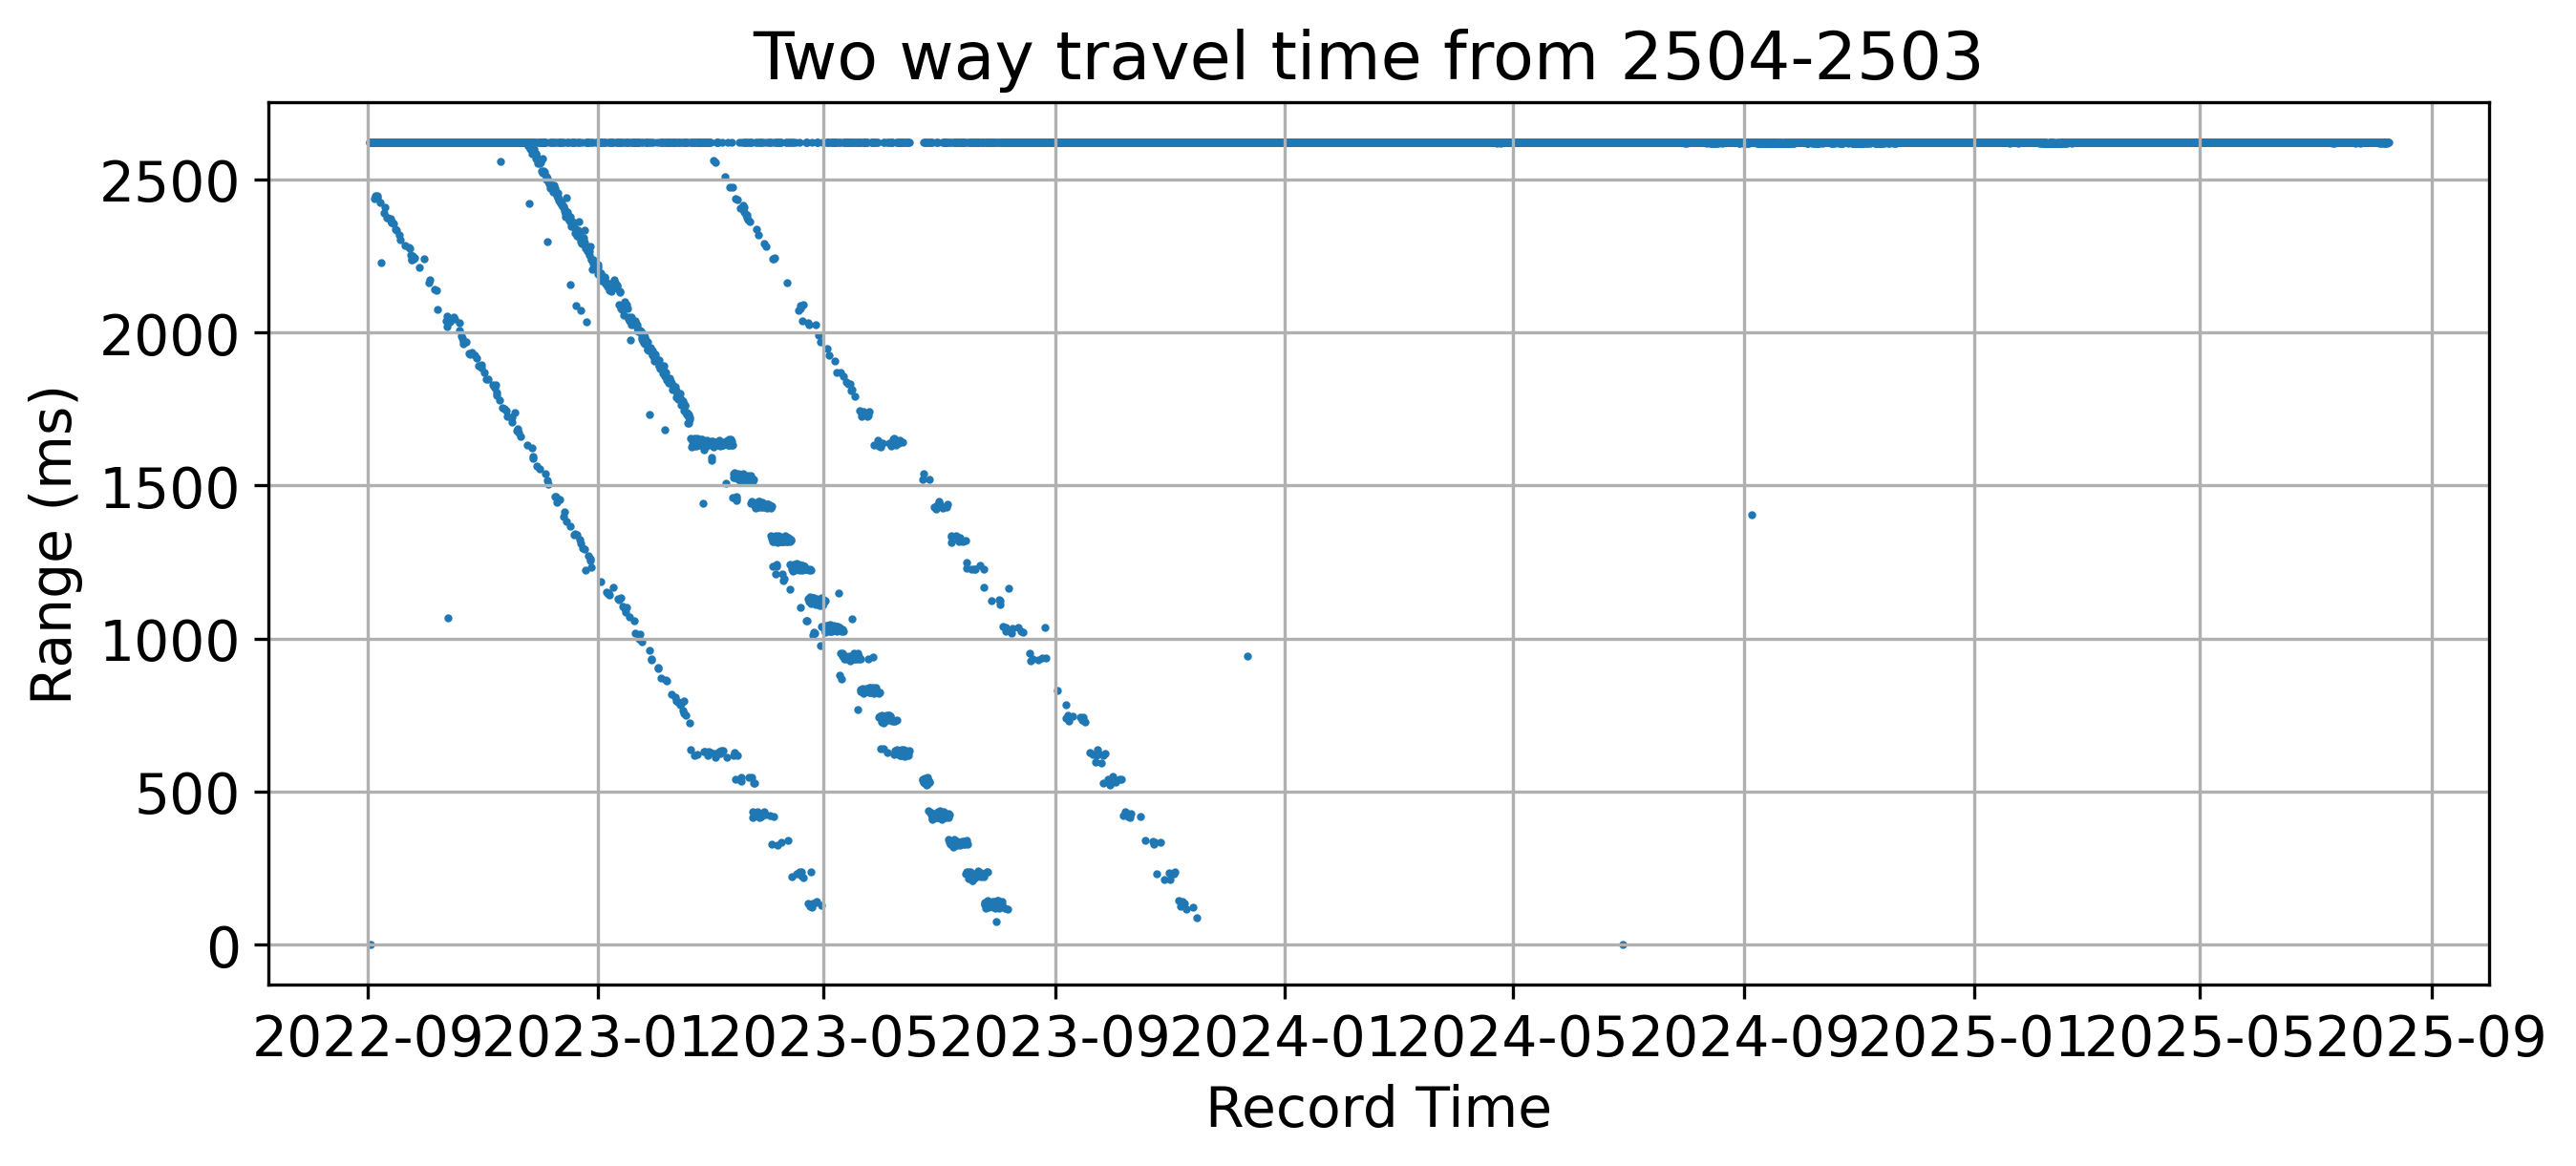

In [77]:
bsl_df = df_dict['2504']['BSL']
bsl_df['RangeAddress'] = bsl_df['RangeAddress'].astype(int).astype(str)
bsl_df['Range(ms)'] = pd.to_numeric(bsl_df['Range(ms)'], errors='coerce')
bsl_df['TAT(ms)'] = pd.to_numeric(bsl_df['TAT(ms)'], errors='coerce')
bsl_2503_df = bsl_df[bsl_df['RangeAddress'] == '2503'].copy()

plt.figure(figsize=(10, 4))
plt.scatter(pd.to_datetime(bsl_2503_df['Record Time']),bsl_2503_df['Range(ms)'],s=1)
plt.title('Two way travel time from 2504-2503 ')
plt.xlabel('Record Time')
plt.ylabel('Range (ms)')
plt.grid(True)
plt.rcParams.update({'font.size': 14})
plt.show()


In [78]:
# Extract DataFrames based on the 'RangeAddress' column values
bsl_df = df_dict['2504']['BSL']
bsl_df['RangeAddress'] = bsl_df['RangeAddress'].astype(int).astype(str)
bsl_df['Range(ms)'] = pd.to_numeric(bsl_df['Range(ms)'], errors='coerce')
bsl_df['TAT(ms)'] = pd.to_numeric(bsl_df['TAT(ms)'], errors='coerce')
bsl_2501_df = bsl_df[bsl_df['RangeAddress'] == '2501'].copy()
bsl_2502_df = bsl_df[bsl_df['RangeAddress'] == '2502'].copy()
bsl_2503_df = bsl_df[bsl_df['RangeAddress'] == '2503'].copy()

# Calculate the IQR for the 'Range(ms)' column in bsl_2502_df
Q1 = bsl_2502_df['Range(ms)'].quantile(0.15)
Q3 = bsl_2502_df['Range(ms)'].quantile(0.85)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


total_rows1 = len(bsl_2502_df)

# Filter out outliers
filtered_bsl_2502_df = bsl_2502_df[(bsl_2502_df['Range(ms)'] >= lower_bound) & (bsl_2502_df['Range(ms)'] <= upper_bound)]
outside_values_df1 = bsl_2502_df[(bsl_2502_df['Range(ms)'] < lower_bound) | (bsl_2502_df['Range(ms)'] > upper_bound)]

# Number of rows after removing outliers
rows_after_filtering1 = len(filtered_bsl_2502_df)
# Calculate the number of outlier rows
num_outliers1 = total_rows1 - rows_after_filtering1
# Calculate the percentage of outliers
percent_outliers_2504_2502 = (num_outliers1 / total_rows1) * 100


# Convert the 'Range(ms)' column to numeric for plotting
bsl_2503_df['Range(ms)'] = pd.to_numeric(bsl_2503_df['Range(ms)'], errors='coerce')

total_rows = len(bsl_2503_df)

# Filter out data points with 'Range(ms)' values less than 2618 from the original bsl_2503_df
filtered_bsl_2503_df = bsl_2503_df[bsl_2503_df['Range(ms)'] >= 2618]
outside_values_df2 = bsl_2503_df[bsl_2503_df['Range(ms)'] < 2618]


# Convert the 'Range(ms)' column to numeric for plotting
bsl_2502_df['Range(ms)'] = pd.to_numeric(bsl_2502_df['Range(ms)'], errors='coerce')

# Creating explicit copies of the DataFrames to avoid the warning
filtered_bsl_2502_copy = filtered_bsl_2502_df.copy()
filtered_bsl_2503_copy = filtered_bsl_2503_df.copy()

# Create explicit copies to avoid the SettingWithCopyWarning
filtered_bsl_2502_copy = filtered_bsl_2502_df.copy()

ensure_datetime(filtered_bsl_2502_copy, 'Record Time')
ensure_datetime(harmonic_df_dict['2502_2504'], 'Record Time')


# Interpolate sound speed values onto the filtered_bsl_2502_copy timestamps
filtered_bsl_2502_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2502_copy['Record Time'].view(np.int64),
    harmonic_df_dict['2502_2504']['Record Time'].view(np.int64),
    harmonic_df_dict['2502_2504']['HMean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2502_copy['Calculated Distance (m)'] = filtered_bsl_2502_copy['Interpolated Sound Speed'] * ((filtered_bsl_2502_copy['Range(ms)']-filtered_bsl_2502_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel

filtered_bsl_2502_copy['Interpolated Harmonic Velocity'] = np.interp(
    filtered_bsl_2502_copy['Record Time'].view(np.int64),
    harmonic_mean_dfs['2502_2504']['Record Time'].view(np.int64),
    harmonic_mean_dfs['2502_2504']['Harmonic Mean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2502_copy['Harmonic Distance (m)'] = filtered_bsl_2502_copy['Interpolated Harmonic Velocity'] * ((filtered_bsl_2502_copy['Range(ms)']-filtered_bsl_2502_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel

filtered_bsl_2502_copy = apply_tilt_correction(
    filtered_bsl_2502_copy, "2504-2502", baseline_perturb
)

R2504_2502 = filtered_bsl_2502_copy
#-------------------------------------------------------------------------------------------------------


# Create an explicit copy of filtered_bsl_2503_df to avoid the SettingWithCopyWarning
filtered_bsl_2503_copy = filtered_bsl_2503_df.copy()

ensure_datetime(filtered_bsl_2503_copy, 'Record Time')
ensure_datetime(harmonic_mean_dfs['2503_2504'], 'Record Time')

# Interpolate sound speed values onto the filtered_bsl_2503_copy timestamps
filtered_bsl_2503_copy['Interpolated Sound Speed'] = np.interp(
    filtered_bsl_2503_copy['Record Time'].view(np.int64),
    harmonic_df_dict['2503_2504']['Record Time'].view(np.int64),
    harmonic_df_dict['2503_2504']['HMean']
)

# Calculate distance using the interpolated sound speeds
filtered_bsl_2503_copy['Calculated Distance (m)'] = filtered_bsl_2503_copy['Interpolated Sound Speed'] * ((filtered_bsl_2503_copy['Range(ms)']-filtered_bsl_2503_copy['TAT(ms)']) / 2000)  # Dividing by 2000 to convert ms to seconds and account for two-way travel



# Interpolate Harmonic Mean Velocity onto the filtered_bsl_2503_copy timestamps
filtered_bsl_2503_copy['Interpolated Harmonic Velocity'] = np.interp(
    filtered_bsl_2503_copy['Record Time'].view(np.int64),
    harmonic_mean_dfs['2503_2504']['Record Time'].view(np.int64),
    harmonic_mean_dfs['2503_2504']['Harmonic Mean']
)

# Calculate distance using the interpolated Harmonic Mean Velocity
# Remember to divide the time (Range - TAT) by 2000 to convert ms to seconds and for two-way travel
filtered_bsl_2503_copy['Harmonic Distance (m)'] = filtered_bsl_2503_copy['Interpolated Harmonic Velocity'] * ((filtered_bsl_2503_copy['Range(ms)'] - filtered_bsl_2503_copy['TAT(ms)']) / 2000)

filtered_bsl_2503_copy = apply_tilt_correction(
    filtered_bsl_2503_copy, "2504-2503", baseline_perturb
)

R2504_2503 = filtered_bsl_2503_copy



/tmp/ipykernel_1763391/3121558529.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])
/tmp/ipykernel_1763391/3121558529.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column_name] = pd.to_datetime(df[column_name])


In [80]:
harmonic_df_dict

{'2502_2503':              Record Time        HMean
 0    2022-09-01 11:45:00  1483.171257
 1    2022-09-01 15:45:00  1483.118281
 2    2022-09-01 19:45:00  1483.092688
 3    2022-09-01 23:45:00  1483.141072
 4    2022-09-02 03:45:00  1483.101092
 ...                  ...          ...
 6364 2025-08-06 15:45:00  1483.163851
 6365 2025-08-06 19:45:00  1483.223439
 6366 2025-08-06 23:45:00  1483.137088
 6367 2025-08-07 03:45:00  1483.253931
 6368 2025-08-07 07:45:00  1483.273557
 
 [6369 rows x 2 columns],
 '2502_2504':              Record Time        HMean
 0    2022-09-02 11:45:00  1484.060266
 1    2022-09-02 15:45:00  1484.013834
 2    2022-09-02 19:45:00  1483.919686
 3    2022-09-02 23:45:00  1483.897964
 4    2022-09-03 03:45:00  1483.953397
 ...                  ...          ...
 6315 2025-08-07 03:45:00  1484.184428
 6316 2025-08-07 07:45:00  1484.245353
 6317 2025-08-07 11:45:00  1484.216502
 6318 2025-08-07 15:45:00  1484.125772
 6319 2025-08-07 19:45:00  1484.057920
 
 [6320 r